### Prompt Chaining Usecase Implementation

Usecase:
* to generate and improvize story based on feedback

In [10]:
#importing libraries

import os
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model

load_dotenv()

True

In [11]:
#base model
model = init_chat_model(model="groq:llama-3.1-8b-instant")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017C6432E570>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017C64332DE0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

#### With LLM Model

In [12]:
#defining state schema
from typing_extensions import TypedDict

from langgraph.graph import START, END, StateGraph

class StoryState(TypedDict):
    topic: str
    story: str = ""
    improved_story: str=""
    final_story: str = ""


In [13]:
#defining story generating node

def generate_story(state:StoryState):
    "this function generates story based on given topic"
    response = model.invoke(f"""generate a simple story about the given topic.
                            Topic: {state['topic']}""")
    return {"story": response.content}

#defining decision node to route based on condition

def judge_story(state: StoryState):
    "this function judegs the story generated"
    if '?' in state['story'] or '!' in state['story']:
        return "fail"
    else:
        return "pass"
    
#defining improvizing story node

def improve_story(state:StoryState):
    "this function improves the story generated by LLM"   
    response = model.invoke(f"""improvize the given story to have a happy ending always.
                            story: {state['story']}""")
    return {"improved_story": response.content}

#defining the final polished story node

def polish_story(state:StoryState):
    "this function generates the final story"
    response = model.invoke(f"""summarize the story given in bullet point format.
                            story: {state['improved_story']}""")
    return {"final_story": response.content}

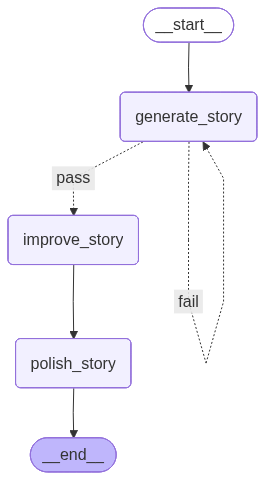

In [14]:
#defining graph nodes and edges and workflow

graph = StateGraph(StoryState)

graph.add_node("generate_story", generate_story)
graph.add_node("improve_story", improve_story)
graph.add_node("polish_story", polish_story)

graph.add_edge(START, "generate_story")
graph.add_conditional_edges("generate_story", judge_story, {"pass": "improve_story", "fail":"generate_story"})
graph.add_edge("improve_story", "polish_story")
graph.add_edge("polish_story", END)

graph_builder = graph.compile()
graph_builder

In [15]:
#invoking graph
state = {"topic":"a boy from small village"}
my_story = graph_builder.invoke(state)
my_story

{'topic': 'a boy from small village',
 'story': "**The Boy from Littleton**\n\nIn a small, quaint village called Littleton, nestled in the rolling hills of the countryside, a young boy named Finnley grew up with a heart full of wonder and curiosity. The village was so small that everyone knew each other's names, and the only sounds you could hear were the chirping of birds, the rustling of leaves, and the gentle hum of the nearby river.\n\nFinnley lived with his widowed mother, Emma, in a cozy little cottage on the outskirts of the village. His father had passed away when Finnley was just a toddler, and Emma had dedicated her life to raising her son, teaching him the values of hard work, kindness, and compassion.\n\nAs a child, Finnley was always fascinated by the world beyond Littleton. He would spend hours listening to the village elder, Old Tom, regale tales of far-off lands, mythical creatures, and great adventures. Finnley's imagination would run wild, conjuring images of exotic j

In [18]:
print(f"Final Story Generated By Model:\n{my_story['final_story']}")

Final Story Generated By Model:
Here's a summary of the story in bullet point format:

**Introduction to Littleton**

* The story takes place in Littleton, a small, quaint village in the countryside.
* Finnley, a young boy, grows up in the village with his widowed mother, Emma.

**Finnley's Childhood**

* Finnley's father passed away when he was a toddler, and Emma raised him with values of hard work, kindness, and compassion.
* Finnley is fascinated by the world beyond Littleton and has a vivid imagination.
* Emma encourages Finnley's curiosity and supports his dreams.

**Finnley's Education**

* At 16, Finnley applies for a scholarship to attend Oakwood Academy, a prestigious boarding school in the nearby city.
* Emma writes a heartfelt letter to the academy's admissions committee, which helps Finnley get accepted and awarded a full scholarship.

**Finnley's Success**

* Finnley thrives at Oakwood Academy, making lifelong friends, excelling in his studies, and discovering a passion f

#####